# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [5]:
print("PLANS:")
display(plans.head())

PLANS:


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
print("\nUSERS:")
display(users.head())


USERS:


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
print("\nUSAGE:")
display(usage.head())


USAGE:


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

En la columna "city" se puede observar que hay 469 valores nulos, lo que se traduce en un 11.7%, rango que determina que es necesario realizar investigacion para imputar o dejarlo como nulo, ya que no es una variable critica para el analisis principal y al imputarlo con el valor tipo "desconocido" seria buena opcion ya que no afecta calculos numericos.
En "churn_date" se establece que el 88.35% de los registros son nulos (3.534 de los 4.000), y la accion recomendada no es eliminar ni imputar, sino dejarlo como esta, ya que no significa un dato faltante real si no que existen usarios que no han cancelado su plan, razon por la cual el indice arrojado asciende casi al 90%.
Ante los resultados arrojados en "usage - date" que se traduce en un 0,125% nulos la accion ideal seria la eliminacion de esas filas ya que es una proporcion minima (50 de 40.000) y el impacto para el analisis seria insignificante, al igual que la fecha es un dato estructural por lo que no hay forma razonable de "predecir o adivinar" una fecha faltante sin introducir sesgo y no tiene sentido imputar una fecha inventada que pueda afectar el analisis.
Finalmente, en "usage- duration" y "usage- length" y sus grandes indices % de nulos (55.19% y 44,74%) cada una, la accion ideal seria verificarlas con "value_counts" de "type" para que los conteos cuadren y dejar la estructura tal cual, analizando "duration" solo para llamadas y "length"solo para mensajes cuando corresponda.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users[['user_id','age']].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` presenta un rango consistente con 4000 registros unicos, iniciando en el ID 10000 hasta el 13999 como maximo, lo cual sugiere IDs consecutivos sin huecos ni duplicados. 
- La columna `age` presenta como edad minima -999, un valor imposible que funciona como sentinel, probablemente usado para marcar datos faltantes o errores de captura y su efecto se puede observar en la desviacion estandar de 123, demasiado alta para una variable como la edad lo que a su vez infla y distorsiona tambien la media, valores no confiables que requieren correccion.

In [15]:
# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


-Las columnas 'id' y 'user_id' son identificadores, no variables medidas donde se confirman 40000 registros unicos sin valores faltantes.
-La columna 'duration' tiene un count de 17924 frente a 40000 filas totales, es decir, cerca de 55% de valores nulos; proporcion demasiado alta para ignorar, su rango va de 0 a 120, donde probablemente el 0 corresponde a llamadas no contestadas y el maximo de 120 se evaluaria contra el percentil 75 para confirmar si es un outlier real o valor valido, dependiendo de si la columna esta en minutos o segundos.
-La columna ´length' tiene un maximo de 1490, muy alejado del percentil 75 (64), lo que indica presencia de outliers: unos pocos valores extremos que se separan bastante del resto de los datos.


In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(users[col].value_counts(dropna=False))
    print()

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Basico     2595
Premium    1405
Name: plan, dtype: int64



- En la columna `city` se identifican dos tipos de inconsistencias en cuanto a los datos, donde uno corresponde al dato "NaN" con 469 valores nulos que ya se habian detectado anteriormente y el otro al valor "?" con 96 registros, este tipo de novedad se considera sentinel, como el -999 que se vio en "age", solo que en este caso es un caracter en lugar de un numero.
- La columna `plan` no hay ningun valor extraño, ya que se establecen dos categorias como lo son "Basico" y "Premium", sin nulos, sin valores inesperados lo que se traduce en una columna limpia y que no requiere ninguna accion.

In [17]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False) # completa el código

text    22092
call    17908
Name: type, dtype: int64

-

 La columna `type` relaciona dos tipos de datos que conforman la duracion de las llamadas y mensajes ya vistas anteriormente y en donde se encuentra la relacion existente entre los nulos de duration y length, que no son datos faltantes por error sino que son esperados por diseño.
Cada fila solo puede tener uno de los dos campos, por que un mensaje no tiene duracion de llamadas y "length" esta vacio cuando la fila es de tipo "call"  



---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  
- En users, la columna "age" presenta una edad minima de -999, un valor imposible que funciona como sentinel, probablemente usado para marcar datos faltantes o errores de captura donde los efectos observables se identifican en la desviacion estandas de 123, demasiada alta para una variable como la edad.
- La columna "city" presenta dos problemas distintos como 469 valores "NaN" y 96 registros con el caracter "?'", que si es un sentinel o valor de relleno usado en lugar de capturar la ciudad real.
- La columna "plan" no presenta ningun valor extraño.
- En "usage", la columna "length" tiene un maximo de 1490, muy alejado del percentil 75 que establece la presencia de outliers (pocos valores extremos que se separan bastante del resto de los datos).
- Por ultimo y no menos importante, los nulos observados inicialmente en "lenght"(44.74%) y "duration" (55,19%), la columna "type" permitio aclarar que no son datos faltantes por error, si no un comportamiento esperado por diseño.

  
- ¿Qué acción tomarías?

- Para age, se reemplazaría el -999 por NaN con users['age'].replace(-999, np.nan), así se busca que se deje de distorsionar la media y la desviación estándar sin perder el resto de la información de esas filas.

Para city, se reemplazaría el "?" por NaN con users['city'].replace('?', np.nan), para que ambos tipos de datos faltantes queden representados de forma consistente y no se traten como una categoría válida en proximos análisis futuros.

En duration y length, no se tomaría ninguna acción sobre los nulos: son consecuencia del diseño de la tabla (una fila solo puede tener duración o longitud, según el tipo de evento), no un error de datos.

Por ultimo; para length, se revisaría los valores por encima del percentil 99 con usage[usage['length'] > usage['length'].quantile(0.99)], con el fin de distinguir si son datos válidos de usuarios de alto consumo o errores de captura, para asi decidir si se corrigen o se dejan como están.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') 

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [20]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se puede observar cuatro años publicados con diferentes registros, donde los tres primeros son consecutivos (2022, 2023 y 2024) y el ultimo corresponde al año 2026 con 40 datos registrados.

In [21]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, se evidencia solo un año el cual es el 2024 con 39950 registros en general y no se evidencia años distintos 

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- No se evidencian años antiguos, no obstante, si se evidencia el año 2026 con 40 registros ya establecidos; lo cual representa una fecha fuera de rango, indicando un posible error de captura.
- ¿Qué harías con ellas?
- Ante el hallazgo evidenciado, este se debe reemplazar por "NaT" o si es posible inferirlo y se puede imputar con la fecha mas cercana valida, documentando la cantidad de registros que se vieron afectados.

  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].isna().sum()

565

In [24]:
# Marcar fechas futuras como NA para reg_date
fecha_corte = pd.Timestamp('2024-12-31')
users.loc[users['reg_date'] > fecha_corte, 'reg_date'] = pd.NaT


# Verificar cambios
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`.

Los valores nulos en la columna "duration" se concentran en los registros de tipo "text", mientras que los nulos en "length" se centran en los registros de tipo "call", por lo que se confirma que los nulos son MAR (Missing At Random) respecto a "type"; la ausencia del dato depende de la naturaleza del registro y no es aleatoria, por esto se dejan como nulos (NaN), ya que no tendria sentido imputar una duracion para un "SMS" ni una longitud de mensaje para una llamada. 


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
#Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")[["is_text", "is_call", "duration"]]
    .sum()
    .reset_index()
)
# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [31]:

# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

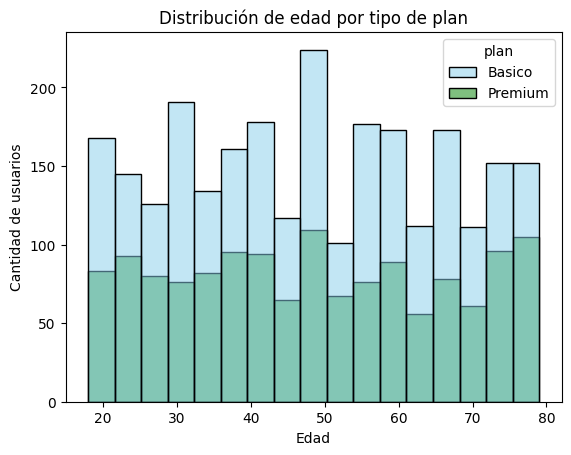

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución de la edad es practicamente uniforme, sin sesgo marcado hacia la derecha o izquierda; los usuarios se distribuyen de forma pareja entre los 18 y los 79 años, con una leve concentracion alrededor de los 45 - 50 años, donde no se observa un patron diferenciado entre los planes basico y premium.

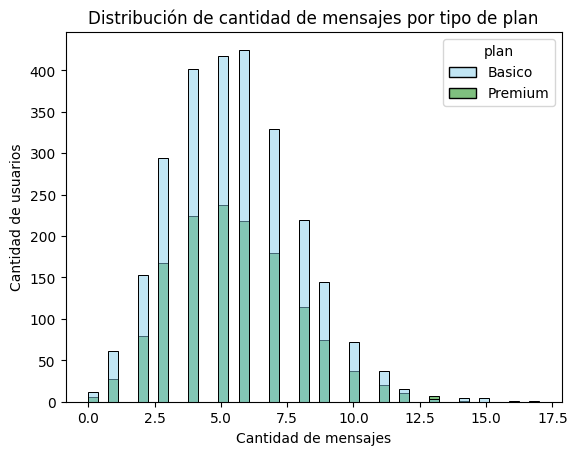

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- En este histograma la distribucion se encuentra sesgada a la derecha donde la mayoria de los usuarios envia entre 4 y 8 mensajes, muy pocos superan los 12-15. En el plan Premium hay una proporcion algo mayor de usuarios en el rango medio-alto de mensajes (5-8), mientras que el plan Basico domina en los valores bajos (0-3 mensajes). Lo anterior sugiere que los usuarios Premium tienden a enviar ligeramente mas mensajes que los del plan Basico.

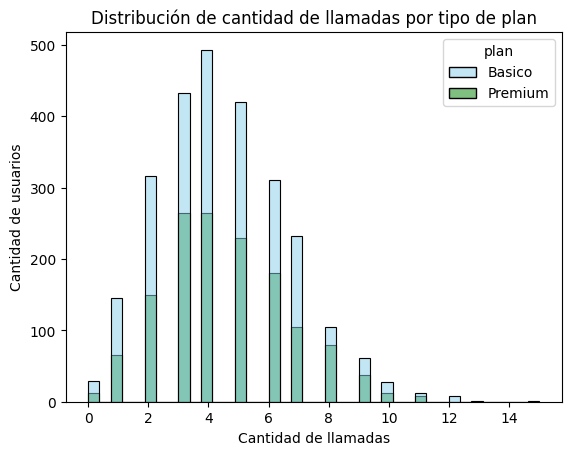

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de cantidad de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Distribución esta sesgada a la derecha, con la mayoria de los usuarios concentrados entre 2 y 6 llamadas. Los usuarios del plan Basico tienden a realizar una cantidad similar o ligeramente mayor de llamadas que los Premium en el rango bajo (0-2), pero ambos planes muestran un comportamiento muy parecido en resto de la distribucion y no existe un patron fuertemente diferenciado entre planes.

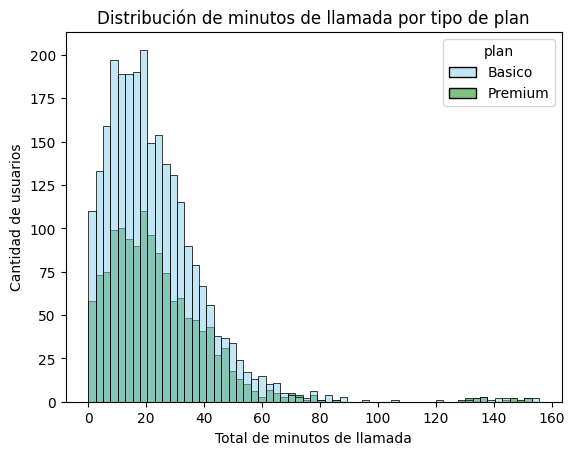

In [35]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de minutos de llamada por tipo de plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡Insights: 
- Esta es la distribucion con el sesgo a la derecha mas notable y marcado de los cuatro histogramas, donde la mayoria de los usuarios acumula entre 10 y 30 minutos de llamadas, pero existe una cola larga que se extiende hasta 140 - 160 minutos, lo que indica la presencia de "outliers"(usuarios con un uso mucho mayor al promedio). El plan Basico concentra mas usuarios en los valores bajos de minutos, mientras que la proporcion de usuarios Premium se mantiene mas constante a lo largo de la cola lo cual sugiere que los usuarios Premium son mas propensos a acumular mas minutos de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

In [36]:
# Visualizando usando Boxplot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


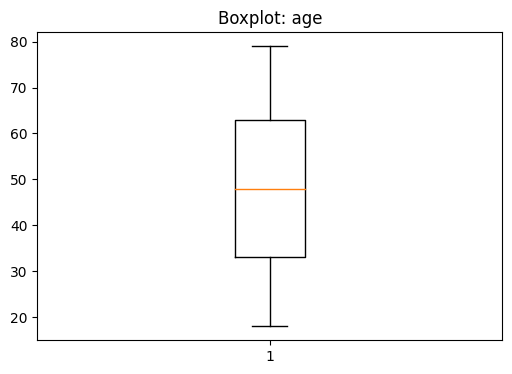

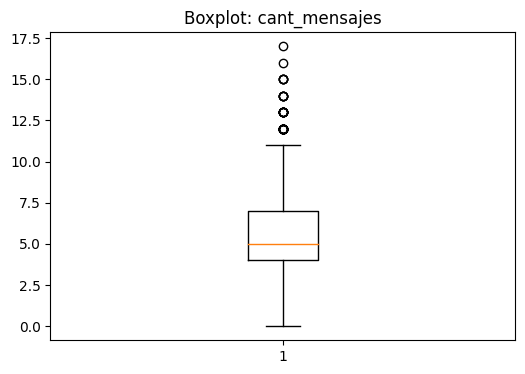

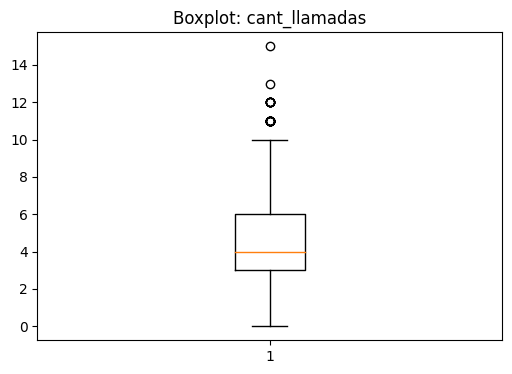

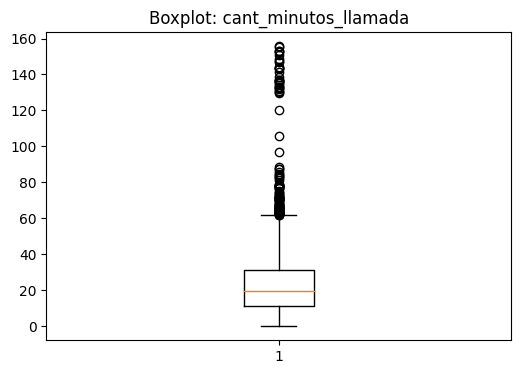

In [37]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:

- Age: La caja y los bigotes cubren todo el rango de datos (de -18 a 80) sin ningun punto marcado fuera de los bigotes por lo que se traduce en una distribucion "limpia" donde no se presentan outliers.
- cant_mensajes: Si presenta outliers al lado supeior donde hay varios puntos por encima del bigote superior (-10 -11), llegando hasta 17-18 mensajes. No hay outliers por el lado inferior ya que el bigote baja hasta 0 sin puntos sueltos.
- cant_llamadas: Si presenta outliers al lado superior, ya que el bigote llega a -9-10 donde hay puntos sueltos hasta 14; por el lado abajo, el bigote llega hasta 0 donde no se observan la presencia de outliers.
- cant_minutos_llamada: Si presenta outliers, y es la variable mas marcada donde el bigote superior corta cerca de 60-65 minutos, pero hay una gran cantidad de puntos muchos concentrados entre 80 y 150 minutos fuera de ese limite. Es la columna con mas outliers de las cuatro, los cuales se encuentran notablemente por el lado superior lo que a su vez transmite usuarios con llamadas muy largas.


In [38]:
# Calcular límites con el método IQR
columnas_limites = []

for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f'{col}: límite inferior = {limite_inferior}, límite superior = {limite_superior}')
    columnas_limites.append(col)


age: límite inferior = -12.0, límite superior = 108.0
cant_mensajes: límite inferior = -0.5, límite superior = 11.5
cant_llamadas: límite inferior = -1.5, límite superior = 10.5
cant_minutos_llamada: límite inferior = -19.322500000000005, límite superior = 61.8575


In [39]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?: Mantener los outliers, aunque hay valores por encima del limite superior (11,5), el maximo real (17) no se aleja demasiado, son usuarios con un uso de mensajeria mas alto de lo comun, pero dentro de un rango plausible donde no hay evidencia de error de captura.
- cant_llamadas: mantener o no outliers, porqué?: Mantener los outliers al igual que el caso de mensajes: el maximo (15) esta moderadamente por encima del limite (10,5). Son valores realistas que representan usuarios con mas llamadas de los habitual, donde no hay errores en los datos
- cant_minutos_llamada: mantener o no outliers, porqué?: Mantenner los outliers, pero documentarlos aparte, ya que la diferencia es mas marcada donde el maximo (155.69) casi triplifica el limite superior (61.86) y hay una cantidad considerable de puntos concentrados entre 80 y 150 minutos. No parecen errores por que no hay valores absurdos, sino un segmento real de usuarios con consumo alto de llamadas. Es coveniente mantenerlos para no perder informacion.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [40]:
# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

opciones_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

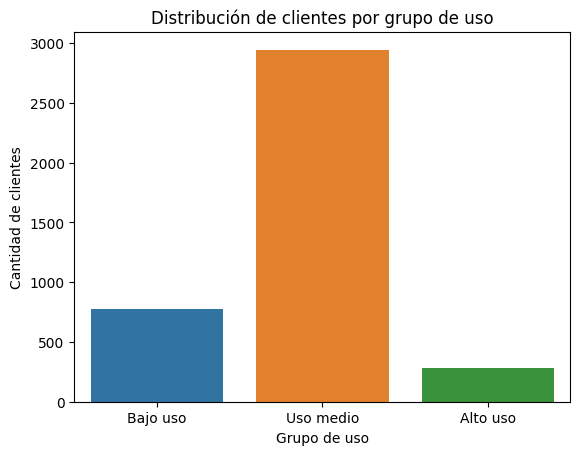

In [44]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()


# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
De acuerdo con informe y sus respectivos hallazagos se describe lo siguiente:
- La columna "age" tenia un valor sentinel (-999) imposible, que fue reemplazado por la mediana (48 años)
- La columna "city" presentaba 469 nulos (11,7%) mas 96 registros con el sentinel "?", sumando 565 valores invalidos (14.1%) del total
- La columma "churn_date" tenia 3,534 nulos (88,35%), aunque en este caso es esperado: representan clientes activos que no se han dado de baja.
- En "reg_date" se encontraron 40 registros con año 2026, una fecha imposible dado que los datos llegan hasta 2024; se marcaron como nulos.
- En "usage", las columnas "duration"(55,2% nulos) y "length"(44,7% nulos) resultaron ser MAR (Missing At Random): dependen del "type" de registro (una llamada no tiene "length" y un mensaje no tiene "duration"), por lo que se dejaron como nulos sin imputar. 


🔍 **Segmentos por Edad**
- Los usuarios se distribuyen de forma practicamente uniforme entre 18 y 79 años, con una leve concentracion entre 45-50 años. 
- No se observo un patron diferenciado en la edad, segun el tipo de plan (Basico vs Premium)


📊 **Segmentos por Nivel de Uso**
- La mayoría de los usuarios envía entre 4-8 mensajes y realiza entre 2-6 llamadas, con distribuciones sesgadas a la derecha.
- Los usuarios Premium tienden a enviar ligeramente más mensajes que los del plan Básico, mientras que en llamadas el comportamiento es similar entre ambos planes.
- Los minutos de llamada muestran el sesgo más marcado: la mayoría se concentra entre 10-30 minutos, pero existe una cola de usuarios que llega hasta 150-160 minutos.


➡️ Esto sugiere que existe un segmento de alto consumo de minutos claramente diferenciado del resto de la base, que podría representar oportunidades comerciales específicas (por ejemplo, migración a planes con más minutos incluidos).


💡 **Recomendaciones**
- Diseñar un plan o add-on para el segmento de Alto uso, orientado a usuarios con consumo elevado de minutos de llamada (outliers reales, no errores de captura), ya que hoy podrían estar pagando de más por excedentes.
- Aprovechar que los usuarios Premium ya muestran mayor uso de mensajería para ofrecerles paquetes de mensajería ilimitada como diferenciador.
- Investigar la causa de los 40 registros con reg_date en 2026 y corregir el proceso de captura de fechas para evitar que se repita.
- Revisar el proceso de captura del campo city para reducir la tasa de valores faltantes/inválidos (14.1% es significativo para segmentación geográfica futura).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`